# 🔬 Skin Cancer Classification — EfficientNetB0
### Fixed: Class Imbalance + Oversampling + Focal Loss

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📁 Step 1: Mount Drive & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATA_DIR = '/content/drive/MyDrive/Skin cancer dataset/organized_datas'
print('✅ Imports done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports done


## 🚀 Step 2: Copy Dataset to Colab Local

In [ ]:
LOCAL_DATA = '/content/organized_datas'

if not os.path.exists(LOCAL_DATA):
    print('Copying from Drive... (2-5 min)')
    shutil.copytree(DATA_DIR, LOCAL_DATA)
    print('✅ Done!')
else:
    print('✅ Already local.')

classes = sorted([c for c in os.listdir(LOCAL_DATA) if os.path.isdir(os.path.join(LOCAL_DATA, c))])
print(f'Classes: {classes}')

for c in classes:
    count = len(os.listdir(os.path.join(LOCAL_DATA, c)))
    print(f'  {c}: {count} images')

Copying from Drive... (2-5 min)
✅ Done!
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
  akiec: 332 images
  bcc: 514 images
  bkl: 1099 images
  df: 115 images
  mel: 1113 images
  nv: 1500 images
  vasc: 142 images


## ⚖️ Step 3: Oversample Minority Classes
> Copies images from small classes until all classes have equal count.
> This directly fixes the `nv` dominance problem.

In [ ]:
import shutil, random
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
import numpy as np

BALANCED_DIR = '/content/organized_balanced'
TARGET_COUNT = 1500  # match the largest class (nv)

if not os.path.exists(BALANCED_DIR):
    os.makedirs(BALANCED_DIR)
    for c in classes:
        src = os.path.join(LOCAL_DATA, c)
        dst = os.path.join(BALANCED_DIR, c)
        os.makedirs(dst, exist_ok=True)

        imgs = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]

        # Copy original images
        for img in imgs:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

        # Oversample if needed
        count = len(imgs)
        extra = TARGET_COUNT - count
        if extra > 0:
            for i in range(extra):
                src_img = random.choice(imgs)
                name, ext = os.path.splitext(src_img)
                # Load, flip, save as new file
                img_arr = img_to_array(load_img(os.path.join(src, src_img)))
                if random.random() > 0.5:
                    img_arr = np.fliplr(img_arr)  # horizontal flip
                else:
                    img_arr = np.flipud(img_arr)  # vertical flip
                new_name = f'{name}_aug{i}{ext}'
                array_to_img(img_arr).save(os.path.join(dst, new_name))

        final_count = len(os.listdir(dst))
        print(f'  {c}: {count} → {final_count} images')

    print('\n✅ Balancing complete!')
else:
    print('✅ Balanced dataset already exists.')
    for c in classes:
        print(f'  {c}: {len(os.listdir(os.path.join(BALANCED_DIR, c)))} images')

  akiec: 332 → 1500 images
  bcc: 514 → 1500 images
  bkl: 1099 → 1500 images
  df: 115 → 1500 images
  mel: 1113 → 1500 images
  nv: 1500 → 1500 images
  vasc: 142 → 1500 images

✅ Balancing complete!


## ✂️ Step 4: Split Balanced Dataset → Train / Val / Test

In [ ]:
!pip install split-folders -q
import splitfolders

OUTPUT_DIR = '/content/dataset_balanced_final'

if not os.path.exists(OUTPUT_DIR):
    splitfolders.ratio(BALANCED_DIR, output=OUTPUT_DIR, seed=42, ratio=(0.70, 0.15, 0.15))
    print('✅ Split complete!')
else:
    print('✅ Already split.')

for split in ['train', 'val', 'test']:
    total = sum(len(os.listdir(os.path.join(OUTPUT_DIR, split, c)))
                for c in os.listdir(os.path.join(OUTPUT_DIR, split)))
    print(f'  {split}: {total} images')

Copying files: 10500 files [00:08, 1174.91 files/s]

✅ Split complete!
  train: 7350 images
  val: 1575 images
  test: 1575 images


## ⚙️ Step 5: Data Generators

In [ ]:
# ✅ No rescale — EfficientNetB0 preprocesses internally
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/train',
    target_size=(224, 224), batch_size=32, class_mode='categorical'
)
validation_generator = val_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/val',
    target_size=(224, 224), batch_size=32, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    f'{OUTPUT_DIR}/test',
    target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

print(f'Train : {train_generator.samples} images')
print(f'Val   : {validation_generator.samples} images')
print(f'Test  : {test_generator.samples} images')
print(f'Classes: {train_generator.class_indices}')

Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Train : 7350 images
Val   : 1575 images
Test  : 1575 images
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


## 🧠 Step 6: Build Model with Focal Loss
> Focal loss penalizes easy/majority class predictions more — directly fixes `nv` bias.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# ── Focal Loss: punishes overconfident wrong predictions ──
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return loss_fn

# ── Build model ──
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True  # ✅ fully unfrozen from start

# Freeze only early layers — fine-tune from layer 100 onwards
for layer in base_model.layers[:100]:
    layer.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu',
      kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu',
      kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),  # ✅ focal loss
    metrics=['accuracy']
)

print('✅ Model compiled with Focal Loss')
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model compiled with Focal Loss


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,843,690 (18.48 MB)

 Trainable params: 4,631,907 (17.67 MB)

 Non-trainable params: 211,783 (827.28 KB)

## 🏋️ Step 7: Train

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=5, min_lr=1e-7, verbose=1
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[checkpoint, reduce_lr]
)

print(f'\n🏆 Best val_accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

Epoch 1/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.2717 - loss: 1.4778
Epoch 1: val_accuracy improved from None to 0.62286, saving model to /content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 256s 827ms/step - accuracy: 0.3683 - loss: 1.3879 - val_accuracy: 0.6229 - val_loss: 1.1937 - learning_rate: 1.0000e-04
Epoch 2/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.5645 - loss: 1.2258
Epoch 2: val_accuracy improved from 0.62286 to 0.71365, saving model to /content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 138s 599ms/step - accuracy: 0.5826 - loss: 1.2015 - val_accuracy: 0.7137 - val_loss: 1.0981 - learning_rate: 1.0000e-04
Epoch 3/40
230/230 ━━━━━━━━━━━━━━━━━━━━

## 📈 Step 8: Training Curves

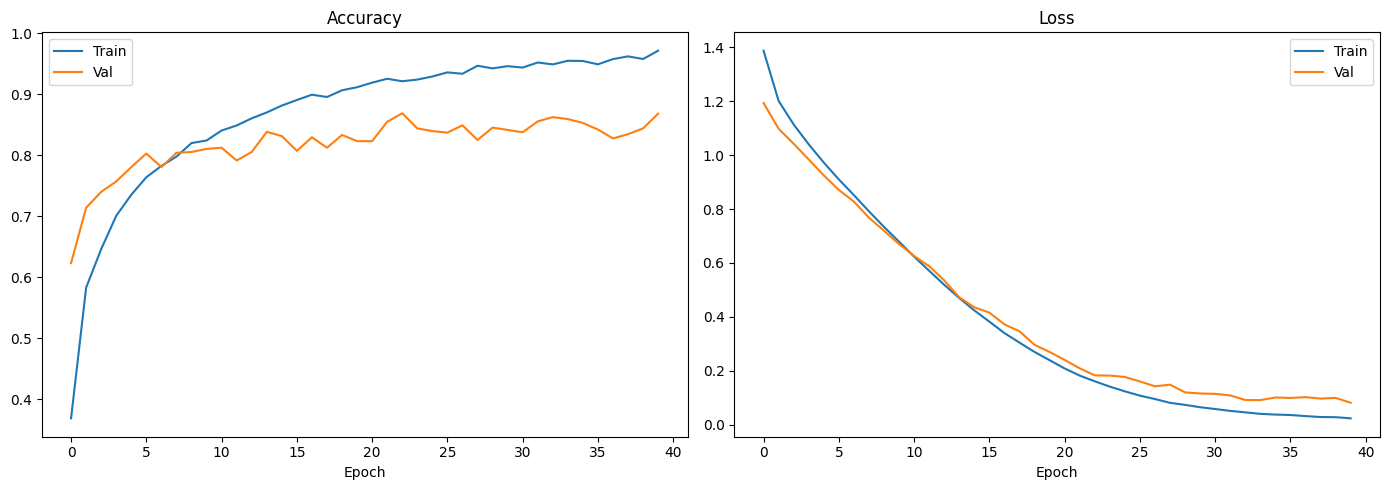

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()

plt.tight_layout()
plt.show()

## ✅ Step 9: Evaluate on Test Set

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/Skin cancer dataset/best_model_balanced.keras',
    custom_objects={'loss_fn': focal_loss()}
)

test_loss, test_acc = model.evaluate(test_generator)
print(f'\n🎯 Final Test Accuracy: {test_acc*100:.2f}%')

model.save('/content/drive/MyDrive/Skin cancer dataset/best_efficientnetb0_final.h5')
print('✅ Saved!')

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.8584 - loss: 0.1880



🎯 Final Test Accuracy: 85.84%
✅ Saved!


## 📋 Step 10: Classification Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
target_names = list(test_generator.class_indices.keys())

print('--- Classification Report ---')
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 366ms/step
--- Classification Report ---
              precision    recall  f1-score   support

       akiec       0.99      0.59      0.74       225
         bcc       0.95      0.94      0.94       225
         bkl       0.66      0.87      0.75       225
          df       1.00      1.00      1.00       225
         mel       0.73      0.82      0.78       225
          nv       0.82      0.80      0.81       225
        vasc       1.00      0.99      0.99       225

    accuracy                           0.86      1575
   macro avg       0.88      0.86      0.86      1575
weighted avg       0.88      0.86      0.86      1575



## 🔲 Step 11: Confusion Matrix

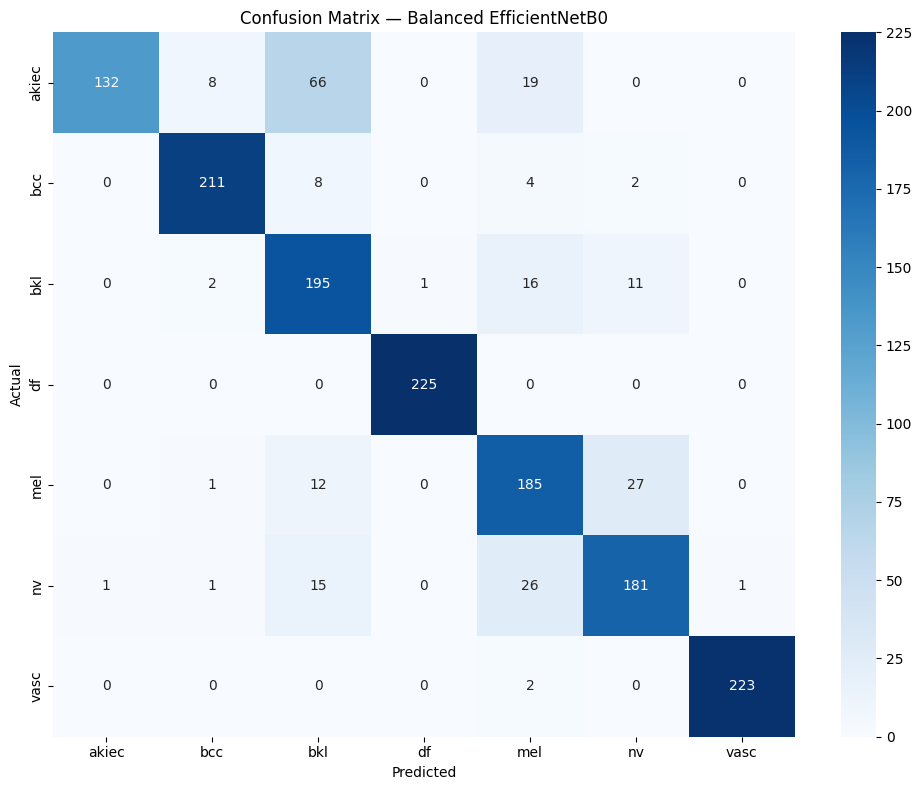

In [ ]:
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Balanced EfficientNetB0')
plt.tight_layout()
plt.show()